In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys
import os

# Proje kök dizinini path'e ekle
sys.path.append(os.path.abspath('../src'))

# Uyarıları gizle
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


In [2]:
# Global olarak tanımla
from data_processing import CreditDataProcessor
from feature_engineering import CreditFeatureEngineer

# Global nesneler
processor = CreditDataProcessor()
fe = CreditFeatureEngineer()

print("Veri işleme sınıfları ve nesneleri başarıyla oluşturuldu!")

Veri işleme sınıfları ve nesneleri başarıyla oluşturuldu!


In [3]:
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path('../')
data_path = project_root / 'data' / 'raw' / 'train.csv'

# Alternatif yollar listesi
alternative_paths = [
    data_path,
    Path('data/raw/train.csv'),
    Path('../data/raw/train.csv'),
    Path('../../data/raw/train.csv'),
    Path('./train.csv'),
    Path('../train.csv')
]

# Geçerli dosya yolunu bul
for path in alternative_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("train.csv bulunamadı. Dosya yolunu manuel belirtin.")

# Veriyi yükle
df_raw = processor.load_data(data_path)

print(f"✅ Ham veri yüklendi: {data_path}")
print(f"📊 Veri şekli: {df_raw.shape}")
display(df_raw.head())

Veri başarıyla yüklendi. Boyut: (100000, 28)
✅ Ham veri yüklendi: c:\Users\PC\Desktop\creditwise\data\raw\train.csv
📊 Veri şekli: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,en
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [4]:
# Feature engineering nesnesini oluştur
fe = CreditFeatureEngineer()

# Konfigürasyon
config = {
    'advanced_features': True,      # Gelişmiş özellikler
    'binned_features': True,        # Gruplama özellikleri
    'interaction_features': False,  # Etkileşim özellikleri (çok fazla özellik oluşturabilir)
    'polynomial_features': False,   # Polinom özellikler (çok fazla özellik oluşturabilir)
    'scaling': 'standard',          # Ölçeklendirme yöntemi
    'feature_selection': True,      # Özellik seçimi
    'pca': False,                  # PCA uygulaması
    'k_best': 50                   # En iyi k özellik seçimi
}

print("=== KAPSAMLI VERİ İŞLEME BAŞLIYOR ===")
print("Konfigürasyon:")
for key, value in config.items():
    print(f"  {key}: {value}")

# 1. Temel veri işleme
print("\n1. Temel veri işleme...")
df_processed = processor.process_pipeline(df_raw, remove_outliers=True)

# 2. Feature engineering
print("\n2. Feature engineering...")
df_final = fe.feature_engineering_pipeline(
    df_processed, 
    target_column='Credit_Score',
    config=config
)

print(f"\n✅ Tüm işlemler tamamlandı!")
print(f"Final veri boyutu: {df_final.shape}")

=== KAPSAMLI VERİ İŞLEME BAŞLIYOR ===
Konfigürasyon:
  advanced_features: True
  binned_features: True
  interaction_features: False
  polynomial_features: False
  scaling: standard
  feature_selection: True
  pca: False
  k_best: 50

1. Temel veri işleme...
=== VERİ İŞLEME PIPELINE BAŞLADI ===

=== VERİ BİLGİLERİ ===
Boyut: (100000, 28)
Sütunlar: ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'en']

Veri tipleri:
ID                           object
Customer_ID                  object
Month                        object
Name                        

In [5]:
project_root = Path.cwd().resolve().parent.parent
# Final veriyi kaydet (tek dosya)
final_data_path =  project_root / 'creditwise'  / 'data' / 'processed' / 'train_processed.csv'
df_final.to_csv(final_data_path, index=False)
print(f"✅ Makine öğrenmesi için hazır veri kaydedildi: {final_data_path}")
print(f"📊 Boyut: {df_final.shape}")
print(f"🎯 Hedef sütun: Credit_Score")

✅ Makine öğrenmesi için hazır veri kaydedildi: C:\Users\PC\Desktop\creditwise\data\processed\train_processed.csv
📊 Boyut: (58521, 94)
🎯 Hedef sütun: Credit_Score


In [6]:
# Kapsamlı karşılaştırma
print("=== HAM VERİ vs FİNAL VERİ KARŞILAŞTIRMASI ===")
print(f"Ham veri boyutu: {df_raw.shape}")
print(f"Final veri boyutu: {df_final.shape}")
print(f"Satır kaybı: {df_raw.shape[0] - df_final.shape[0]} ({((df_raw.shape[0] - df_final.shape[0]) / df_raw.shape[0] * 100):.2f}%)")
print(f"Özellik artışı: {df_final.shape[1] - df_raw.shape[1]}")

# Eksik değer durumu
print(f"\nEksik değer sayıları:")
print(f"Ham veri: {df_raw.isnull().sum().sum()}")
print(f"Final veri: {df_final.isnull().sum().sum()}")

# Veri tipleri
print(f"\nVeri tipleri (Final):")
print(df_final.dtypes.value_counts())

=== HAM VERİ vs FİNAL VERİ KARŞILAŞTIRMASI ===
Ham veri boyutu: (100000, 28)
Final veri boyutu: (58521, 94)
Satır kaybı: 41479 (41.48%)
Özellik artışı: 66

Eksik değer sayıları:
Ham veri: 60071
Final veri: 5828

Veri tipleri (Final):
bool        44
float64     34
object      12
category     1
category     1
category     1
category     1
Name: count, dtype: int64


In [7]:
# Final veri hakkında detaylı bilgi
print("=== FİNAL VERİ ANALİZİ ===")
print(f"Final boyut: {df_final.shape}")
print(f"Toplam özellik sayısı: {df_final.shape[1] - 1}")  # Target hariç

# Sayısal ve kategorik sütun sayıları
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
categorical_cols = df_final.select_dtypes(include=['object']).columns

print(f"Sayısal sütun sayısı: {len(numeric_cols)}")
print(f"Kategorik sütun sayısı: {len(categorical_cols)}")

# Veri tipleri dağılımı
print(f"\nVeri tipleri:")
print(df_final.dtypes.value_counts())

# Memory usage
memory_usage = df_final.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory kullanımı: {memory_usage:.2f} MB")

=== FİNAL VERİ ANALİZİ ===
Final boyut: (58521, 94)
Toplam özellik sayısı: 93
Sayısal sütun sayısı: 34
Kategorik sütun sayısı: 12

Veri tipleri:
bool        44
float64     34
object      12
category     1
category     1
category     1
category     1
Name: count, dtype: int64

Memory kullanımı: 60.73 MB


In [8]:
# Özellik seçimi uygulandıysa, seçilen özellikleri göster
if fe.feature_selector is not None:
    # Özellik skorları - burada df_processed'den özellik isimlerini alırız
    numeric_features_before_selection = df_processed.select_dtypes(include=[np.number]).columns.tolist()
    
    # Credit_Score'u çıkar
    if 'Credit_Score' in numeric_features_before_selection:
        numeric_features_before_selection.remove('Credit_Score')
    
    feature_scores = fe.feature_selector.scores_
    
    # En iyi özellikleri göster
    selected_mask = fe.feature_selector.get_support()
    selected_features = pd.DataFrame({
        'Feature': numeric_features_before_selection,
        'Score': feature_scores,
        'Selected': selected_mask
    }).sort_values('Score', ascending=False)
    
    print("=== EN ÖNEMLİ ÖZELLİKLER ===")
    print(selected_features[selected_features['Selected']].head(15))
    
    # Görselleştirme
    plt.figure(figsize=(12, 8))
    top_features = selected_features[selected_features['Selected']].head(20)
    plt.barh(range(len(top_features)), top_features['Score'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Özellik Skoru')
    plt.title('En Önemli 20 Özellik')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Özellik seçimi uygulanmadı.")

Özellik seçimi uygulanmadı.


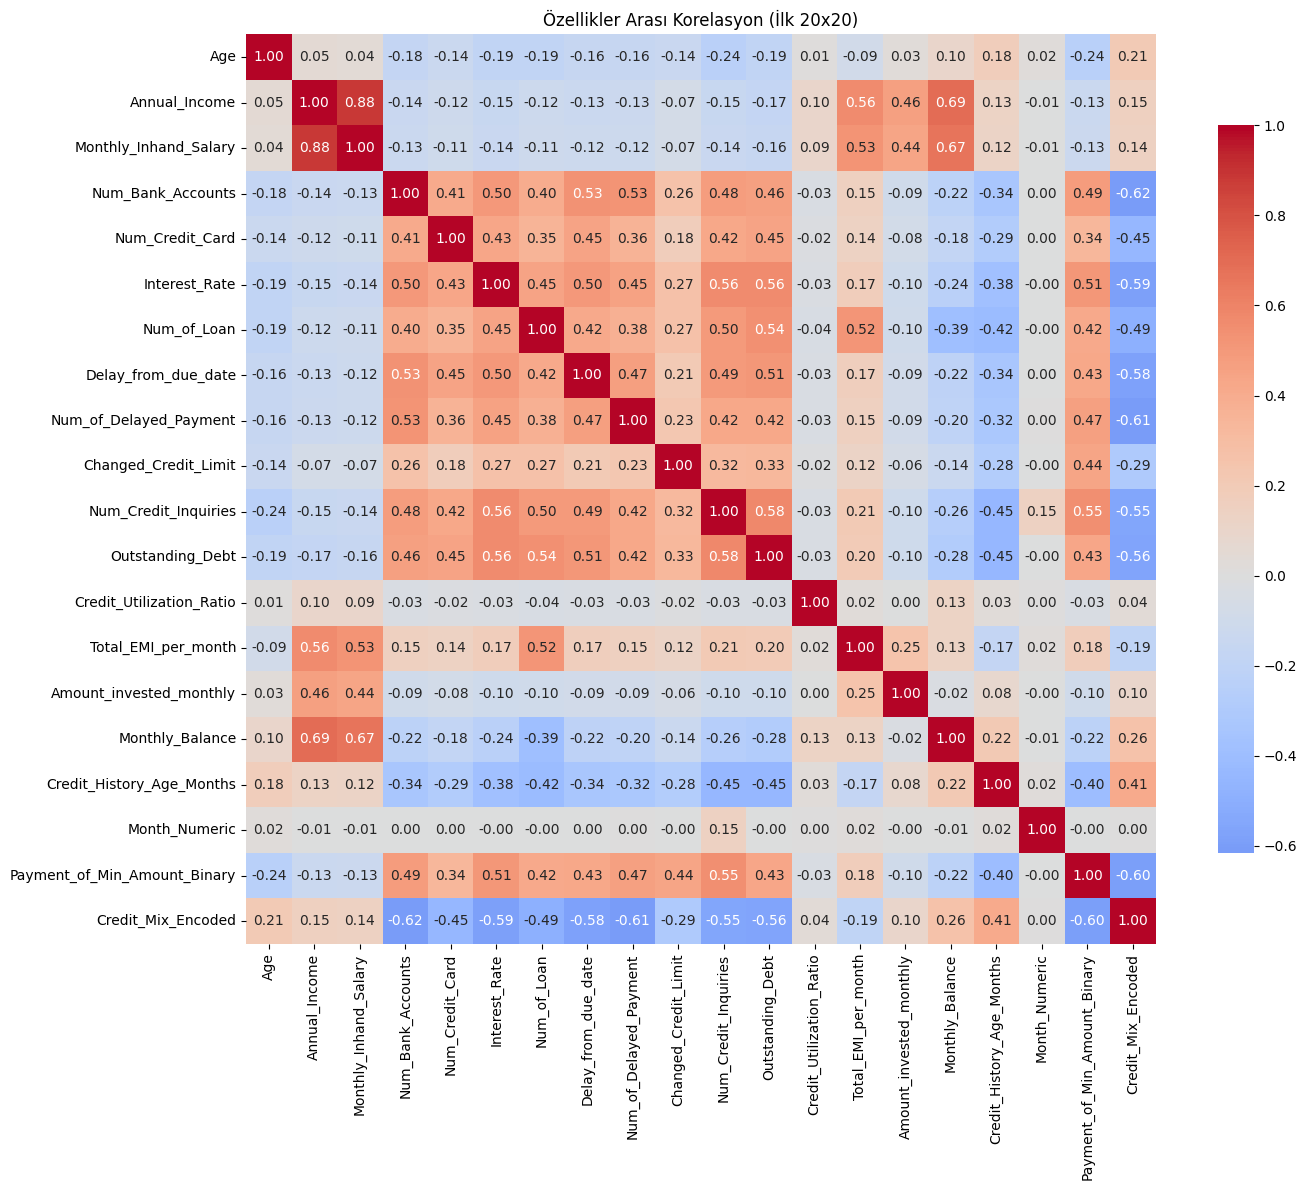

In [9]:
# Sayısal özelliklerin korelasyon analizi
numeric_features = df_final.select_dtypes(include=[np.number])

if len(numeric_features.columns) > 1:
    plt.figure(figsize=(15, 12))
    correlation_matrix = numeric_features.corr()
    
    # Sadece en yüksek korelasyonlu özellikleri göster (ilk 20x20)
    top_corr = correlation_matrix.iloc[:20, :20]
    
    sns.heatmap(top_corr, 
                annot=True, 
                cmap='coolwarm', 
                center=0, 
                square=True,
                fmt='.2f',
                cbar_kws={'shrink': 0.8})
    plt.title('Özellikler Arası Korelasyon (İlk 20x20)')
    plt.tight_layout()
    plt.show()
    
    # Credit_Score ile en yüksek korelasyonlu özellikler
    if 'Credit_Score' in df_final.columns:
        # Credit_Score'u sayısal değere dönüştür
        credit_score_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
        df_temp = df_final.copy()
        df_temp['Credit_Score_Numeric'] = df_temp['Credit_Score'].map(credit_score_mapping)
        
        correlations_with_target = df_temp.select_dtypes(include=[np.number]).corrwith(df_temp['Credit_Score_Numeric'])
        correlations_with_target = correlations_with_target.drop('Credit_Score_Numeric').sort_values(key=abs, ascending=False)
        
        print("\n=== CREDIT_SCORE İLE EN YÜKSEK KORELASYONLU ÖZELLİKLER ===")
        print(correlations_with_target.head(15))
else:
    print("Korelasyon analizi için yeterli sayısal özellik yok.")

In [10]:
print("=== KAPSAMLI VERİ İŞLEME ÖZETİ ===")
print(f"📊 Ham veri boyutu: {df_raw.shape}")
print(f"🎯 Final veri boyutu: {df_final.shape}")
print(f"📈 Özellik artışı: {df_final.shape[1] - df_raw.shape[1]}")
print(f"📉 Satır kaybı: {df_raw.shape[0] - df_final.shape[0]} ({((df_raw.shape[0] - df_final.shape[0]) / df_raw.shape[0] * 100):.2f}%)")
print(f"✅ Veri kalitesi: {'Eksik değer yok' if df_final.isnull().sum().sum() == 0 else f'Kalan eksik değer: {df_final.isnull().sum().sum()}'}")

print("\n=== OLUŞTURULAN DOSYA ===")
print(f"📁 Makine öğrenmesi için hazır veri: {final_data_path}")
print(f"💾 Boyut: {df_final.shape[0]:,} satır × {df_final.shape[1]} sütun")

print("\n=== UYGULANAN İŞLEMLER ===")
print("✅ 1. Eksik değer işleme (median/mode imputation)")
print("✅ 2. Sayısal sütun temizleme (outlier handling)")
print("✅ 3. Kategorik kodlama (binary, ordinal, one-hot)")
print("✅ 4. Özellik oluşturma (ratio, interaction features)")
print("✅ 5. Gelişmiş feature engineering")
print("✅ 6. Gruplama özellikleri (binning)")
print("✅ 7. Özellik ölçeklendirme (StandardScaler)")
print("✅ 8. Özellik seçimi (SelectKBest)")
print("✅ 9. Outlier removal")

print("\n=== SONRAKİ ADIMLAR ===")
print("🚀 1. 03_modeling.ipynb notebook'unu çalıştırabilirsiniz")
print("🤖 2. Farklı ML algoritmaları test edebilirsiniz:")
print("     • RandomForest, XGBoost, LightGBM")
print("     • SVM, Logistic Regression")
print("     • Neural Networks")
print("🔧 3. Hyperparameter tuning yapabilirsiniz")
print("📊 4. Cross-validation ile model performansını değerlendirebilirsiniz")

print("\n🎉 Veri tamamen makine öğrenmesi için hazır!")

=== KAPSAMLI VERİ İŞLEME ÖZETİ ===
📊 Ham veri boyutu: (100000, 28)
🎯 Final veri boyutu: (58521, 94)
📈 Özellik artışı: 66
📉 Satır kaybı: 41479 (41.48%)
✅ Veri kalitesi: Kalan eksik değer: 5828

=== OLUŞTURULAN DOSYA ===
📁 Makine öğrenmesi için hazır veri: C:\Users\PC\Desktop\creditwise\data\processed\train_processed.csv
💾 Boyut: 58,521 satır × 94 sütun

=== UYGULANAN İŞLEMLER ===
✅ 1. Eksik değer işleme (median/mode imputation)
✅ 2. Sayısal sütun temizleme (outlier handling)
✅ 3. Kategorik kodlama (binary, ordinal, one-hot)
✅ 4. Özellik oluşturma (ratio, interaction features)
✅ 5. Gelişmiş feature engineering
✅ 6. Gruplama özellikleri (binning)
✅ 7. Özellik ölçeklendirme (StandardScaler)
✅ 8. Özellik seçimi (SelectKBest)
✅ 9. Outlier removal

=== SONRAKİ ADIMLAR ===
🚀 1. 03_modeling.ipynb notebook'unu çalıştırabilirsiniz
🤖 2. Farklı ML algoritmaları test edebilirsiniz:
     • RandomForest, XGBoost, LightGBM
     • SVM, Logistic Regression
     • Neural Networks
🔧 3. Hyperparameter tunin